In [89]:
# importing essential modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [90]:
# import dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [91]:
# reading dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [92]:
 # Drop a useless column
df = df.drop(columns=['customerID'])

In [93]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [94]:
 # Review dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [95]:
# Percentage of missing values per column
(df.isnull().sum())*100/len(df)

gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [96]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [97]:
# converting the categorical values to numerical values (0, 1)
binary_map = {'Yes' : 1, 'No' : 0, 'Male' : 1, 'Female' : 0}
binary_cols = ['gender','Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map(binary_map)

In [98]:
# converting the categorical values to numerical values (0, 1) 
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [99]:
# converted categorical variables into dummy variables
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True, dtype=int)

In [101]:
# converted "TotalCharges" from object to numeric
# invalid values are conveted to NAN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# fill the missing values in "TotalCharges" with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)  

In [77]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0


In [78]:
# finding columns data type
df.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                int64
InternetService_No                         int64
Contract_One year                          int64
Contract_Two year   

In [79]:
# finding realationship between features
corr = df.corr(numeric_only=True)

corr['Churn'].sort_values(ascending=False)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV                              0.063228
StreamingMovies                          0.061382
MultipleLines                            0.040102
PhoneService                             0.011942
gender                                  -0.008612
DeviceProtection                        -0.066160
OnlineBackup                            -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport                             -0.164674
OnlineSecurity                          -0.171226
Contract_One year                       -0.177820


In [80]:
# Split the dataset into train and test
X = df.drop(columns=['Churn'])
y = df['Churn']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(

    X,
    y,
    random_state= 42, 
    test_size=0.2,
    stratify=y
)

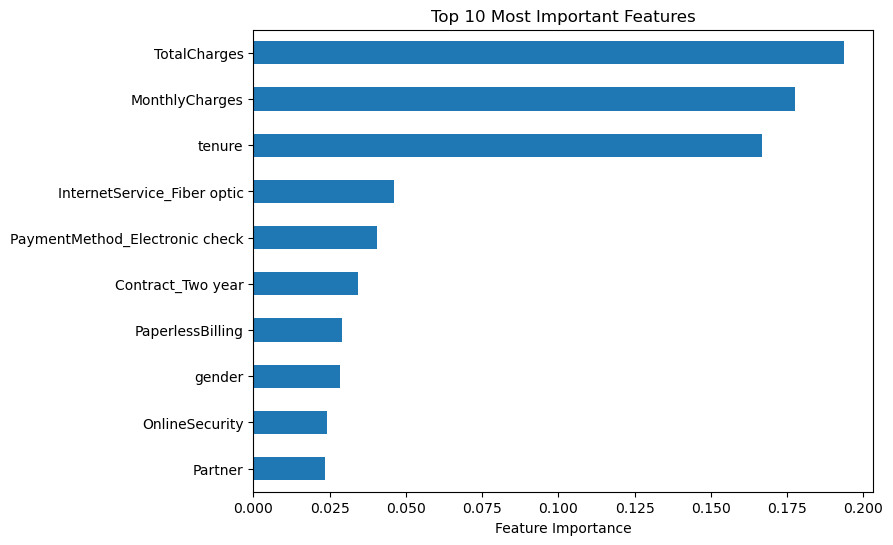

In [81]:
 # create a feature importance ranking
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

 # visualize the top 10 important features
plt.figure(figsize=(8,6))
importance.head(10).plot(kind='barh')
plt.xlabel("Feature Importance")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

In [82]:
# define the hyperparameter search space for Random Forest
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [83]:
# generate the random forrest model
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1')

In [84]:
print(random_search.best_params_)
print(random_search.best_score_)


{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
0.5641627434790601


In [85]:
# split the dataset into train and test 
X = df[['TotalCharges','MonthlyCharges','tenure','InternetService_Fiber optic',
        'PaymentMethod_Electronic check','Contract_Two year','OnlineSecurity',                        
        'Partner', 'Contract_One year','OnlineBackup','SeniorCitizen','TechSupport',                              
        'MultipleLines', 'Dependents','DeviceProtection','StreamingMovies',                          
        'StreamingTV','InternetService_No','PaymentMethod_Mailed check',               
        'PaymentMethod_Credit card (automatic)']]

y = df['Churn']

X_train, X_test, y_train, y_test= train_test_split(

    X,
    y,
    stratify=y,
    random_state= 42, 
    test_size=0.2
)

In [40]:
# generating random forrest model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    bootstrap=True,
    random_state=42,
    n_jobs=-1)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [44]:
# evaluate the model accuracy
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8034066713981547
ROC-AUC: 0.8429060425224107

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409


Confusion Matrix:
[[937  98]
 [179 195]]


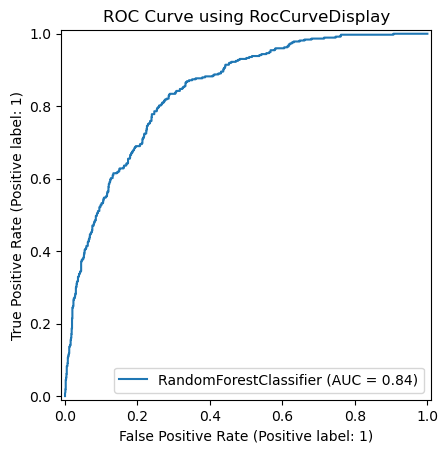

In [46]:
from sklearn.metrics import RocCurveDisplay
# plot the ROC curve for the random forrest
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax)
ax.set_title("ROC Curve using RocCurveDisplay")
plt.show()

In [47]:
from xgboost import XGBClassifier

# generate the XGBoost classifier model
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metrics="logloss"
)

In [49]:
# train the model using the train data
model.fit(X_train, y_train)

C:\Users\Mohamad\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:04:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, eval_metrics='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, ...)

In [50]:
# predict the target value for test data
y_pred = model.predict(X_test)

In [51]:
# evaluate the model accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7991483321504613


In [52]:
# print the model's report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



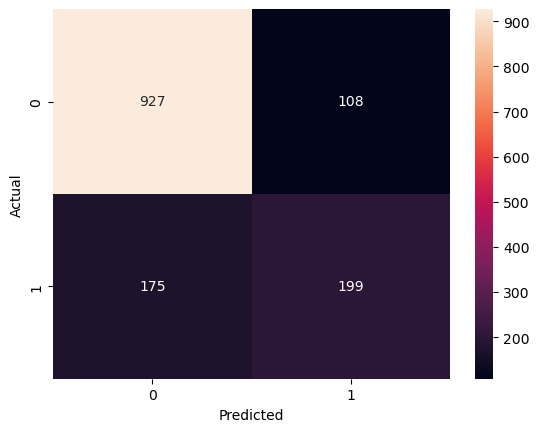

In [53]:
# plot the confusion matrix 
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
# get probabilities for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# calculate the ROC-AUC score 
auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8419773179363972


In [54]:
from sklearn.model_selection import cross_val_score
# evaluate the model using 5-fold cross-validation with ROC-AUC scoring
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print("Mean:", scores.mean())

C:\Users\Mohamad\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:06:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mohamad\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:06:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mohamad\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:06:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Mohamad\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:06:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iterati

[0.84956212 0.85512155 0.82654034 0.83407416 0.84306313]
Mean: 0.8416722583199341


In [55]:
from sklearn.model_selection import GridSearchCV

# use GridSearchCV to find the best ones
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [56]:
# train the GridSearchCV model on the training data
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [57]:
# print the best parameter
print(grid.best_params_)
# print the cross-validation score
print(grid.best_score_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
0.8472358320306699


In [58]:
# get the best model from GridSearchCV
final_model = grid.best_estimator_

In [59]:
# make predictions on the test set
y_pred = final_model.predict(X_test)

In [61]:
# print the model's classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [62]:
# get probabilities for the positive class
y_prob = final_model.predict_proba(X_test)[:, 1]

# claculate the ROC-AUC score
print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

ROC-AUC: 0.8441292722622646
